In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("ami10o0 version:", amigo.__version__)
print("dorito version:", dorito.__version__)

ERROR:2026-08-26 00:09:20,542:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


cpu
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
ami10o0 version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

# compile caching
if device.device_kind != "cpu":
    # if gethostname().startswith("max-"):
    #     jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    #     jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    #     jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    #     jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

    stats = device.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"]
    print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
    print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
    print(f"Free       : {free / 1024**3:.2f} GB")


if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 1000
# intermediate_prints = [100, 1000, 5000, 10000, 15000]
# intermediate_prints = [200, 5000]
# intermediate_prints = [25]
intermediate_prints = []
# intermediate_prints = list(range(1000, 19000, 2000))
n_files_per_filt = 4
n_vals_per_filt = 1
one_filt_flag = False
binary_flag = False
val_flag = True
flat_flag = False
flat_only = False
static_optics = False
plot_flag = check_script()
# plot_flag = True
save_flag = check_script()
recalculate_flag = False
# best_state = load_dict(amigo_files_path + "/scratch_final_state.npy")
# best_state = load_dict(amigo_files_path + "/final_statev21.npy")
best_state = load_dict(amigo_files_path + "/best_statev25.npy")


if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)

    job_name = os.environ.get("SLURM_JOB_NAME")
    if job_name is not None:
        job_id = "_".join([job_id, job_name])
    
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None


print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-cpuv3-0-12
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


In [3]:
from retrain_fns import summarise_files
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)

# # Add extra bad pixels
# badpix = np.load(f"{cache_dir}/full_badpix.npy")
# # badpix = np.load(f"{cache_dir}/full_badpix.npy")
# badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    # if file[0].header["PROGRAM"] == "04481" and file[0].header["FILTER"] == "F430M":
    #     file["BADPIX"].data[30, 40] = 1
    return file


## Validation files
Calibrators from other science programs

In [4]:
def sort_files(files, n):
    files.sort(key=lambda x: (x[0].header["PROGRAM"], x[0].header["FILTER"], x[0].header["PATT_NUM"]), reverse=True)
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}
    for filt in filts:
        x = []
        for file in files:
            if file[0].header["FILTER"] == filt:
                if one_filt_flag and filt != "F480M":
                    continue
                x.append(file)
        these_files[filt] = x[0:n]
    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

In [5]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []

# Collated validator subset
program_path = os.path.join(data_dir, "VAL_SUBSET/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = sort_files(files, n_vals_per_filt)
val_files += files

# Adding bad pixels and summarising metadata
val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

  program     target filter dither     g/i        date              PI   CAL
0    1843  HD-205827  F480M    1/1  10/641  26-10-2022  Kammerer, Jens  True
1    1843  HD-205827  F380M    1/1  3/7800  26-10-2022  Kammerer, Jens  True
2    1843  HD-205827  F430M    1/1  7/1885  26-10-2022  Kammerer, Jens  True


## Calibration files
The main training data, including flats.

In [6]:
calpsf_files = []
calbin_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
calpsf_files += files
calpsf_files = [add_badpix(file) for file in calpsf_files]
calpsf_files = sort_files(calpsf_files, n_files_per_filt)
summarise_files(calpsf_files)

print()
print("CAL8330 - Benjamin Pope")
program_path = os.path.join(data_dir, "8330/calslope/")
files = get_files(program_path, "nis_calslope")
calbin_files += files
calbin_files = [file for file in calbin_files if file[0].header["NGROUPS"] > 3]
calbin_files = [add_badpix(file) for file in calbin_files]
calbin_files = sort_files(calbin_files, n_files_per_filt)
summarise_files(calbin_files)

CAL4481 - Anand Sivaramakrishnan
   program    target filter dither      g/i        date                       PI   CAL
0     4481  HD-41094  F480M    2/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1     4481  HD-41094  F480M    3/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
2     4481  HD-41094  F480M    4/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
3     4481  HD-41094  F480M    5/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
4     4481  HD-41094  F380M    2/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
5     4481  HD-41094  F380M    3/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
6     4481  HD-41094  F380M    4/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
7     4481  HD-41094  F380M    5/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
8     4481  HD-41094  F430M    2/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True
9     4481  HD-41094  F430M    3/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True
10    4481

Flats.

In [7]:
flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files
# flat_files = [file for file in flat_files if file[0].header["NGROUPS"] != 45]
flat_files = sort_files(flat_files, n_files_per_filt)

flat_files = [add_badpix(file) for file in flat_files]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    1503  UNKNOWN  F380M    1/1  30/10  04-02-2023  Martel, Andre  FLAT
1    1503  UNKNOWN  F480M    1/1  30/10  16-03-2023  Martel, Andre  FLAT


# Exposures

In [8]:
from amigo.model_fits import PointFit

class UniqueAbPointFit(PointFit):
    def get_key(self, param):
        match param:
            case "aberrations":
                return "_".join((self.filter, self.key))

        return super().get_key(param)

In [9]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
calpsf_exposures = [PointFit(file) for file in calpsf_files]
calbin_exposures = [BinaryFit(file) for file in calbin_files]
val_exposures = [UniqueAbPointFit(file) for file in val_files]
flat_exposures = [FlatFit(file) for file in flat_files]
# dark_exposures = [DarkFit(file) for file in dark_files]

if binary_flag:
    cal_exposures = calpsf_exposures + calbin_exposures
else:
    cal_exposures = [*calpsf_exposures]

exposures = [*cal_exposures]
if val_flag:
    exposures += val_exposures
if flat_flag:
    exposures += flat_exposures
if flat_only:
    exposures = [*flat_exposures]

print(f"Total number of exposures: {len(exposures)}")

# just closing the files
files = calpsf_files + calbin_files + val_files + flat_files# + dark_files
_ = [f.close() for f in files]

Total number of exposures: 15


Finally, let's batch the exposures for training.

In [10]:
from amigo.fitting import batch_exposures

bs = 3
# bs = 1 if one_filt_flag else 3

# Get the batches: Calibrator, flats, and validators
cal_batch = batch_exposures(cal_exposures, batch_size=bs, key="cal")
flat_batch = batch_exposures(flat_exposures, batch_size=bs, key="flat")
val_batch = batch_exposures(val_exposures, batch_size=bs, key="val")
# dark_batch = batch_exposures(dark_exposures, batch_size=bs, key="dark")
nn_batches = {**cal_batch, **flat_batch}

# Building model

In [11]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from retrain_fns import nn_setup_options

nn_arch = nn_setup_options[2]
# nn_arch = nn_setup_options[job_index]

optics = AMIOptics(static=static_optics)

# Get the model
model = AmigoModel(
    exposures=exposures,
    # optics=AMIOptics(),
    optics=optics,
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(**nn_arch),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)
print(nn_arch, model.nn_weights.shape)

{'hidden_width': 12, 'n_hidden_layers': 3} (5616,)


Populate from state.

In [12]:
state = load_dict(amigo_files_path + "/calibration.npy")

print(model.aberrations.keys())

if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
    del state["jitter"]
    
for key, value in state.items():
    print(key)
    if key == "transmission" and not static_optics:
        continue
    if key in ["primary_beam", "distortion"] and static_optics:
        continue
    if key in [
        'aberrations',
        # 'primary_beam',
        # 'distortion',
        # 'transmission',
        'badpix',
    ]:
        continue
    model = model.set(key, value)

if not flat_only:
    ab_dict = {}
    for key, _ in model.aberrations.items():
        try:
            prog, filt = key.split("_")
        except ValueError:
            ids = key.split("_")
            if len(ids) > 1:
                filt = ids[0]
            else:
                filt = "F430M"
        try:        
            ab_dict[key] = state["aberrations"][filt]
        except KeyError:
            ab_dict[key] = state["aberrations"]["F430M"]
            
    model = model.set("aberrations", ab_dict)

print()
for key, value in best_state.items():
    print(key)
    if key in [
        'positions',
        # 'flat_coeffs',
        'fluxes',
        'aberrations',
        'nn_weights',
        'primary_beam',
        'distortion',
        # 'FF',
        # 'non_linearity',
        'sigma',
        'defocus',
        'dark_current',
    ]:
        if key in model.params.keys():
            # model = model.set(key, value)
            default = model.get(key)
            model = model.set(key, default | value)
        else:
            model = model.set(key, value)

# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.0
ff = ff.at[badpix].set(1.0)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

if not flat_only:
    spec_dic = model.spectra
    spec_dic["HD-41094_F380M"] = np.array(-0.12454516)
    spec_dic["HD-41094_F430M"] = np.array(-0.14548536)
    spec_dic["HD-41094_F480M"] = np.array(-0.12436274)
    model = model.set("spectra", spec_dic)
                                          
if binary_flag:
    for exp in calbin_exposures:
        model = model.set(
            exp.map_param("pas"),
            np.array(66.31),
        )
        model = model.set(
            exp.map_param("separations"),
            np.array(0.1259),
        )
        model = model.set(
            exp.map_param("contrasts"),
            np.array(0.376),
        )
    spec_dic = model.spectra
    spec_dic["V-EZ-Aqr_F380M"] = np.array([-0.07376706, -0.07606107])
    spec_dic["V-EZ-Aqr_F430M"] = np.array([-0.14906244, -0.14530317])
    spec_dic["V-EZ-Aqr_F480M"] = np.array([-0.12971859, -0.12976371])
    model = model.set("spectra", spec_dic)

dict_keys(['04481_F380M', '04481_F430M', '04481_F480M', 'F380M_01843_002_01_05_1', 'F430M_01843_002_01_06_1', 'F480M_01843_002_01_04_1'])
FF
SRF
non_linearity
dark_current
defocus
nn_weights
aberrations
transmission
badpix
sigma

FF
aberrations
dark_current
defocus
distortion
fluxes
non_linearity
positions
primary_beam
sigma
spectra
nn_weights


## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

In [13]:
from amigo.plotting import summarise_fit

if plot_flag and not flat_only:
    if save_flag:
        this_save_path = os.path.join(save_path, "init_cal")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
    for exp in cal_exposures:
        exp.print_summary()
        # try:
        summarise_fit(model, exp, save_path=this_save_path)
        # except Exception as e:
            # print(f"Plotting failed: {e}")
            # pass

Now the validator exposures.

In [14]:
if plot_flag:
    if val_flag:
        if save_flag:
            this_save_path = os.path.join(save_path, "init_val")
            os.mkdir(this_save_path)
        else:
            this_save_path = None
        for exp in val_exposures:
            print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints, exp.filename)
            summarise_fit(model, exp, save_path=this_save_path)

Finally, the flats and darks.

In [15]:
if plot_flag:
    if flat_flag:
        if save_flag:
            this_save_path = os.path.join(save_path, "init_flat")
            os.mkdir(this_save_path)
        else:
            this_save_path = None
        for exp in flat_exposures:
            print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
            summarise_fit(model, exp, save_path=this_save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [16]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    # grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    sep_reg,
    pa_reg,
    linear_reg,
    temp_decay,
    cosine_warmup,
)

from retrain_fns import get_warmup, get_temperature


def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    # flat field
    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    # non linearity
    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    # spectra clipping
    if hasattr(model_params, "spectra"):
        spectra = model_params.spectra
        clip_fn = lambda x: np.clip(x, a_min=-0.8, a_max=0.8)
        spectra = jax.tree.map(clip_fn, spectra)
        model_params = model_params.set("spectra", spectra)

    return model_params, args

cal_stars = ["HD-41094", "V-EZ-Aqr"]

def grads_fn(model, grads, args):

    # Get the parameters
    grad_params = grads.params

    if "spectra" in grad_params.keys():
        for key, val in grad_params["spectra"].items():
            for star in cal_stars:
                if star in key:
                    val = jax.tree.map(lambda x: 0*x, val)
                    grad_params["spectra"][key] = val
    
    if "nn_weights" not in grad_params.keys():
        return grads, args

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    values = grad_params["nn_weights"]
    temp = get_temperature(args)
    rand_vals = temp * jr.normal(key, values.shape)
    values += rand_vals

    # Add the learning rate warm-up (we also warm up the temperature here)
    values *= args["max_lr"] * get_warmup(args)

    # Increment the t parameter
    args["t"] += 1.0 / args["n_batch"]

    grad_params["nn_weights"] = values
    grads = grads.set("params", grad_params)

    return grads, args

    
# REGULARISATION
reg_dict = {
    "FF": (1.0, ff_reg),
    "NL": (1.0, nl_reg),
    "PA": (1.0, sep_reg),
    "SEP": (1.0, pa_reg),
    "LIN": (10.0, linear_reg),
}

In [48]:
def linear_penalty(y, eps=1e-8):
    """
    Mean squared residual from the best-fit line through y,
    assuming equispaced samples (x = 0, 1, ..., n-1).
    0 = perfectly linear (any slope, including flat).
    """
    n = y.shape[0]  # number of timesteps
    x = np.arange(n)

    y = (y - np.min(y)) / (np.max(y) - np.min(y) + eps)  # for range offset
    # y = (y - np.mean(y)) / (np.mean(y) + eps)  # for mean offset

    x_centered = x - (n - 1) / 2.0  # can just use midpoint for x mean
    y_centered = y - np.mean(y)

    Sxy = np.sum(x_centered * y_centered)
    Sxx = np.sum(x_centered ** 2)
    Syy = np.sum(y_centered ** 2)

    ss_res = Syy - (Sxy ** 2) / Sxx
    return ss_res / n


def linear_reg(model, exposure, args, return_im=False):

    # getting slopes out of args
    slopes = args["slopes"]
    slope_vec = slopes.reshape(slopes.shape[0], -1)

    # calculating linear penalty per pixel
    lin_pen = jax.vmap(linear_penalty, in_axes=1)(slope_vec)

    if return_im:
        return lin_pen.reshape(slopes.shape[-2], slopes.shape[-1])
    return np.mean(lin_pen)

In [49]:
exp = cal_exposures[1]
slopes = exp(model)
args = {"slopes": slopes}
im = linear_reg(model, exp, args, return_im=True)

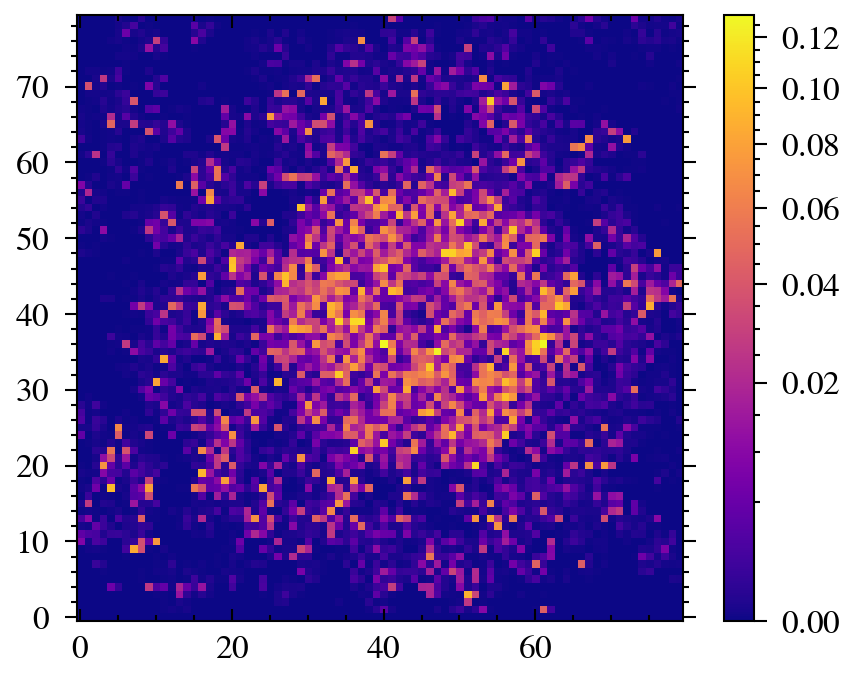

In [50]:
plt.imshow(im, "plasma", norm=mpl.colors.PowerNorm(0.5))
plt.colorbar()
plt.show()

In [51]:
# def linear_penalty(y, eps=1e-8):
#     """
#     Mean squared residual from the best-fit line through y,
#     assuming equispaced samples (x = 0, 1, ..., n-1).
#     0 = perfectly linear (any slope, including flat).
#     """
#     n = y.shape[0]  # number of timesteps
#     x = np.arange(n)

#     # plt.plot(y)
#     # normalising by mean instead of range to avoid div by 0
#     y = (y - np.min(y)) / (np.max(y) - np.min(y))
#     y2 = (y - np.mean(y)) / (np.mean(y) + eps)
#     plt.plot(y, label="range")
#     plt.plot(y2, label="mean")
    

#     x_centered = x - (n - 1) / 2.0  # can just use midpoint for x mean
#     y_centered = y - np.mean(y)

#     Sxy = np.sum(x_centered * y_centered)
#     Sxx = np.sum(x_centered ** 2)
#     Syy = np.sum(y_centered ** 2)

#     ss_res = Syy - (Sxy ** 2) / Sxx

#     plt.legend()
#     plt.show()
#     return ss_res / n

# y0 = slopes[:, 40, 40]
# linear_penalty(y0)

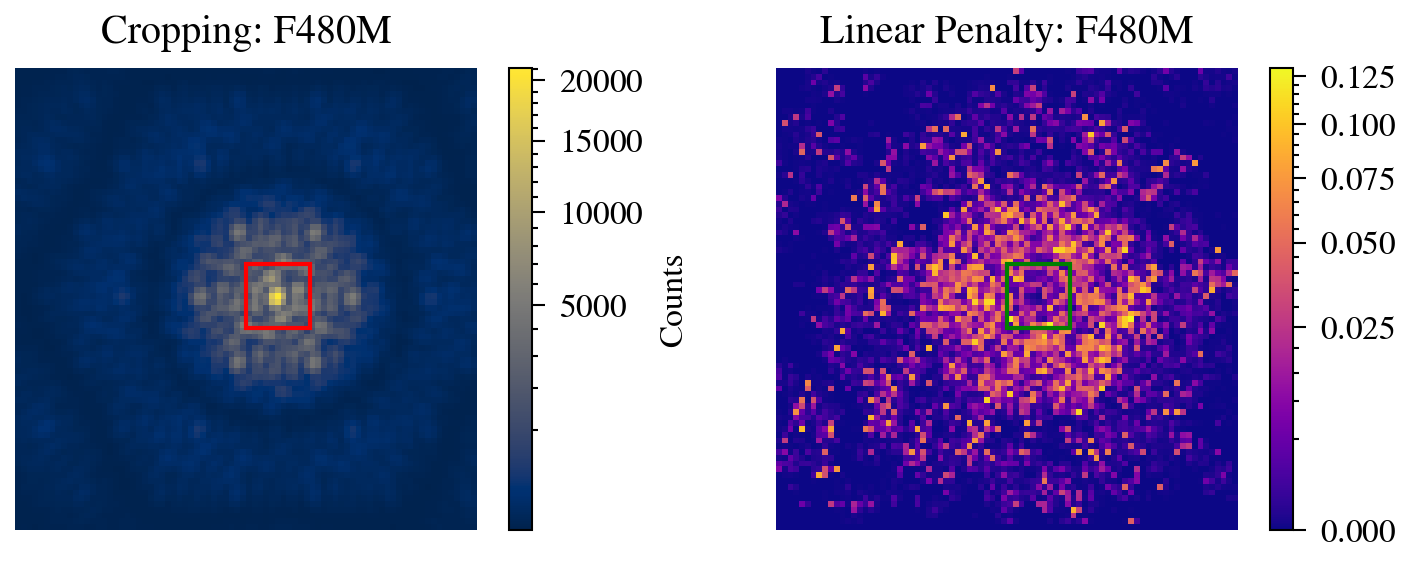

In [52]:
# from retrain_fns import convert_adjacent_to_true
from amigo.misc import convert_adjacent_to_true

n = 5
k = 2 * n + 1


slopes = exp(model)
im = slopes.sum(0)
peak_pix = im == np.nanmax(im)
peak_map = convert_adjacent_to_true(peak_pix, corners=True, n=n)

slope_vec = slopes.reshape(slopes.shape[0], -1)    
linpen = jax.vmap(linear_penalty, in_axes=1)(slope_vec).reshape(slopes.shape[-2], slopes.shape[-1])

######### plotting #########
max_loc = np.argwhere(peak_pix)[0][::-1]

fig, ax = plt.subplots(1, 2, figsize=(6, 2))
c = ax[0].imshow(im, "cividis", norm=mpl.colors.PowerNorm(0.5))
ax[0].set(title=f"Cropping: {filt}")
fig.colorbar(c, ax=ax[0], label="Counts")
ax[1].set(title=f"Linear Penalty: {filt}")
c = ax[1].imshow(linpen, "plasma", norm=mpl.colors.PowerNorm(.5))
fig.colorbar(c, ax=ax[1])
for i, color in zip([0, 1], ["r", "g"]):
    square = mpl.patches.Rectangle(max_loc - np.array([k/2, k/2]), k, k, color=color, fill=False)
    ax[i].axis("off")
    ax[i].add_patch(square)
if save_flag:
    plt.savefig(os.path.join(this_save_path, f"{typ}_crop_{filt}.png"), dpi=300)
    plt.close()
else:
    plt.show()
############################

ind = np.where(peak_map)
model_slopes = slopes[:, *ind].reshape(-1, k, k)
data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5

xs = np.arange(len(slopes))

fig, axes = plt.subplots(k, k, figsize=(3 * k, 3 * k), sharex="col")
# fig.suptitle(filt)

for i in range(k):
    for j in range(k):
        ax = axes[i, j]

        if i == k - 1:
            ax.set_xlabel("Slope Index")
        else:
            ax.tick_params(labelbottom=False)
        if j == 0:
            ax.set_ylabel("Slope (e- / group)")

        ax.errorbar(
            xs, data_slopes[:, i, j], yerr=data_std[:, i, j],
            marker='o', capsize=5, label="Data",
        )
        ax.errorbar(
            xs, model_slopes[:, i, j],
            marker='x', capsize=5, label="Model"
        )
        ax.legend()

# fig.tight_layout()
if save_flag:
    plt.savefig(os.path.join(this_save_path, f"{typ}_slope_{filt}.png"), dpi=300)
    plt.close()
else:
    plt.show()

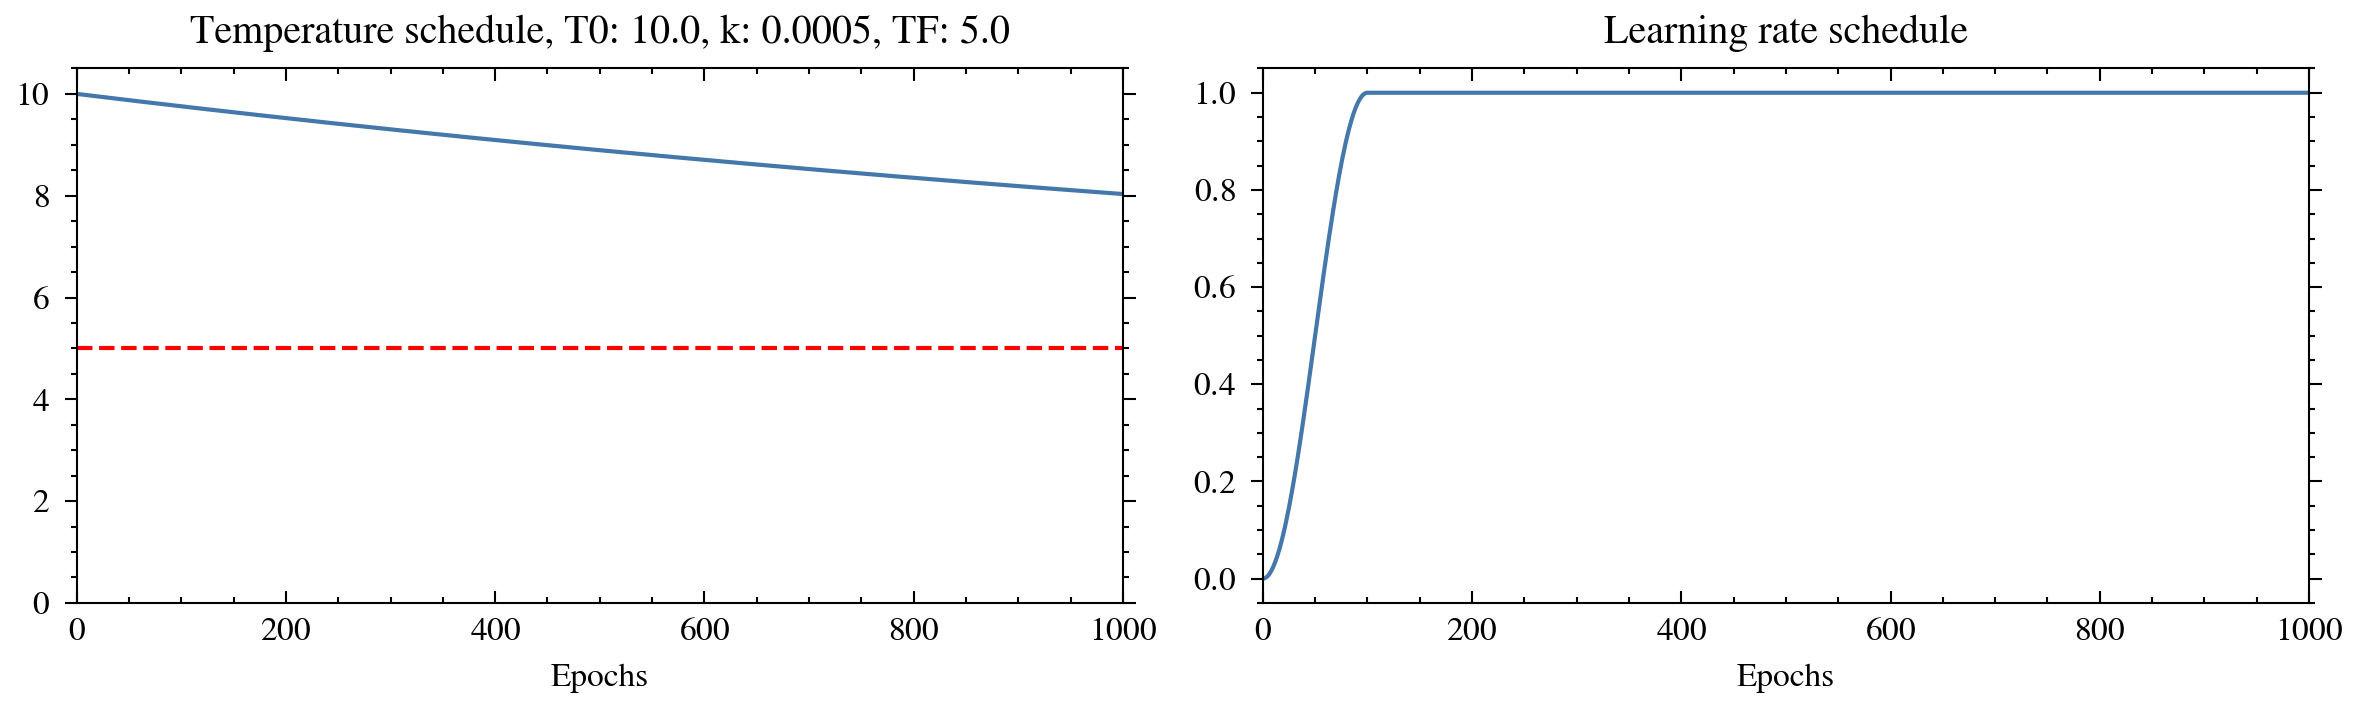

In [20]:
n_batch = len(nn_batches)

# WARM UP
max_lr = 1.  # Learning rate after warm up
t0 = 0  # Warm-up start
n_max = 100  # Warm-up end

# TEMPERATURE DECAY
T0 = 1e1  # Initial temperature
TF = 5e0  # Final temperature
# T0 = 1e-6  # Initial temperature
# decay = 0.005  # Decay rate of the temperature
decay = 5e-4  # Decay rate of the temperature

args = {
    "n_batch": np.array(n_batch, float),  # Number of batches
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "T0": np.array(T0),  # Initial temperature
    "TF": np.array(TF),  # Final temperature
    "k": np.array(decay),  # Decay rate
    "t0": np.array(t0),  # Warm-up start
    "n_max": np.array(n_max),  # Warm-up end point
    "l2": np.array(0.0),
    "max_lr": np.array(max_lr),  # Learning rate after warm up
    "reg_dict": reg_dict,
}

ts = np.arange(epochs)
temps = temp_decay(t=ts, T0=args["T0"], k=args["k"], TF=args["TF"])
lrs = cosine_warmup(ts, args["t0"], args["n_max"])
l2s = 0 * cosine_warmup(ts, 0, 1000)
args = {**args, **{"l2_schedule": l2s}}


fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
ax[0].set(title=f"Temperature schedule, T0: {args["T0"]}, k: {args["k"]}, TF: {args["TF"]}", xlabel="Epochs", ylim=(0, 1.05*T0), xlim=(0, epochs))
ax[0].axhline(TF, linestyle='--', color="red")
ax[0].plot(ts, temps, label="Temperature")
ax[1].set(title="Learning rate schedule", xlabel="Epochs", xlim=(0, epochs))
ax[1].plot(ts, lrs, label="Learning rate")

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "schedules.png"), dpi=200)
    plt.close()
else:
    plt.show()

Instantiating trainer class and updating fishers.

In [21]:
from amigo.calibration import ValBatchedTrainer, BatchedTrainer, Trainer  # , looper_fn, aux_fn
# from dorito.stats import apply_regularisers
from retrain_fns import summarise_fn

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer_class = ValBatchedTrainer if val_flag else Trainer

trainer_class_kwargs = {
    "loss_fn": loss_fn,
    "args_fn": args_fn,
    "grad_fn": grads_fn,
    "norm_fn": norm_fn,
    "summarise_fn": summarise_fn,
    "intermediate_prints": intermediate_prints,
    "save_path": save_path,
    "cache": cache_dir,
}

if val_flag:
    trainer_class_kwargs["aux_fn"] = aux_fn
    trainer_class_kwargs["looper_fn"] = looper_fn   

trainer = trainer_class(**trainer_class_kwargs)

# TODO should there be all the detector parameters here?
if flat_flag:
    print("Flat exposures")
    trainer = trainer.update_fishers(
        linear_model,
        flat_exposures,
        parameters=["flat_coeffs", "fluxes"],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

if val_flag:
    print("Val exposures")
    trainer = trainer.update_fishers(
        linear_model,
        val_exposures,
        batch_size=10,
        parameters=["positions", "aberrations", "fluxes", "spectra"],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

if not flat_only:
    print("Batched cal")
    ps = ["aberrations", "defocus"]
    if not static_optics:
        ps += ["distortion", "primary_beam"]
    trainer = trainer.update_fishers(
        linear_model,
        cal_exposures,
        batch_size=10,
        parameters=ps,
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

    print("Unbatched cal")
    trainer = trainer.update_fishers(
        linear_model,
        cal_exposures,
        parameters=[
            "positions",
            "fluxes",
            "spectra",
            "sigma",  # formerly jitter
            "dark_current",
        ],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )
    
    if binary_flag:
        print("Binary Exposures")
        trainer = trainer.update_fishers(
            linear_model,
            calbin_exposures,
            parameters=[
                "pas",
                "separations",
                "contrasts",
            ],
            recalculate=recalculate_flag,
            overwrite=recalculate_flag,
        )

Val exposures


  0%|          | 0/3 [00:00<?, ?it/s]

Batched cal


  0%|          | 0/12 [00:00<?, ?it/s]

Unbatched cal


  0%|          | 0/12 [00:00<?, ?it/s]

Training.

In [19]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    "fluxes": sgd(1e-3, 0),
    "flat_coeffs": sgd(1e-3, 0),
    "positions": sgd(1e-3, 2),
    "aberrations": sgd(1e-4, 5),
    "pas": sgd(2e-3, 5),
    "separations": sgd(5e-4, 7),
    "contrasts": sgd(5e-4, 8),
    "nn_weights": sgd(1e-5, 0),  # lr applied with warm up
    # "defocus": sgd(1e-3, 25),
    # "distortion": sgd(5e-5, 30),
    # "dark_current": sgd(2e-3, 35),
    # "primary_beam": sgd(1e-5, 40),
    # "sigma": sgd(1e-3, 50),  # start at 50th?
    # "non_linearity": sgd(1e-4, 100),
    # "FF": sgd(2e-5, 150),
    # "spectra": sgd(1e-3, 20),
}

if not binary_flag:
    bin_ps = ["pas", "separations", "contrasts"]
    optimisers = {key: val for key, val in optimisers.items() if key not in bin_ps}

if not flat_flag:
    flat_ps = ["flat_coeffs"]
    optimisers = {key: val for key, val in optimisers.items() if key not in flat_ps}

if not val_flag:
    val_ps = ["spectra"]
    optimisers = {key: val for key, val in optimisers.items() if key not in val_ps}

if static_optics:
    dyn_ps = ["distortion", "primary_beam"]
    optimisers = {key: val for key, val in optimisers.items() if key not in dyn_ps}
    
        
print(optimisers.keys())
# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

if flat_flag:
    batches = {**cal_batch, **flat_batch} if not flat_only else flat_batch
else:
    batches = cal_batch

summarise_kwargs = {
    "val_flag": val_flag,
    "flat_flag": flat_flag,
    "binary_flag": binary_flag,
    "save_flag": save_flag,
    "flat_only": flat_only,
    "static_optics": static_optics,
    "cal_exposures": cal_exposures,
    "val_exposures": val_exposures,
    "flat_exposures": flat_exposures,
    "calpsf_exposures": calpsf_exposures,
    "calbin_exposures": calbin_exposures,
    "badpix": badpix,
    "n_batch": n_batch,
    "optimisers": optimisers,
    "amigo_files_path": amigo_files_path,
}

common_trainer_kwargs = {
    "model": model,
    "optimisers": optimisers,
    "epochs": epochs,
    "batches": batches,
    "args": args,
    "summarise_kwargs": summarise_kwargs,
}

if val_flag:
    if "nn_weights" in optimisers.keys():
        common_trainer_kwargs["batched_params"] = ["nn_weights"]
    else:
        common_trainer_kwargs["batched_params"] = []

val_trainer_kwargs = {
    "validators": val_batch,
    "validator_params": ["positions", "fluxes", "aberrations", "spectra"]
    }

trainer_kwargs = {**common_trainer_kwargs, **val_trainer_kwargs} if val_flag else common_trainer_kwargs

# with jax.disable_jit():
result = trainer.train(**trainer_kwargs)

dict_keys(['fluxes', 'positions', 'aberrations', 'nn_weights'])


  0%|          | 0/1000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling Loss function...
Compiling update function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling update function...
Compile time: 0:03:12

Initial_loss Loss: 32.06
Compiling Loss function...
Estimated run time: 10:01:00


E0821 02:05:23.523506    6967 pjrt_stream_executor_client.cc:2091] Execution of replica 0 failed: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/runpy.py", line 198, in _run_module_as_main
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/runpy.py", line 88, in _run_code
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
  File "/home/dg

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
    handle._run()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 621, in shell_main
    await self.dispatch_shell(msg, subshell_id=subshell_id)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 478, in dispatch_shell
    await result
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 372, in execute_request
    await super().execute_request(stream, ident, parent)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 834, in execute_request
    reply_content = await reply_content
                    ^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 464, in do_execute
    res = shell.run_cell(
          ^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/ipykernel/zmqshell.py", line 663, in run_cell
    return super().run_cell(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3169, in run_cell
    result = self._run_cell(
             ^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3224, in _run_cell
    result = runner(coro)
             ^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/IPython/core/async_helpers.py", line 128, in _pseudo_sync_runner
    coro.send(None)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3446, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3687, in run_ast_nodes
    if await self.run_code(code, result, async_=asy):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3747, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_6967/2452342966.py", line 12, in <module>
    summarise_fit(model, exp, save_path=this_save_path)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/amigo/plotting.py", line 58, in summarise_fit
    slopes = exposure(model)
             ^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/amigo/model_fits.py", line 398, in __call__
    return self.simulate(model, return_slopes=return_slopes).data
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/equinox/_module/_prebuilt.py", line 34, in __call__
    return self.__func__(self.__self__, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/amigo/model_fits.py", line 390, in simulate
    ramp = self.model_ramp(illuminance, model)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/equinox/_module/_prebuilt.py", line 34, in __call__
    return self.__func__(self.__self__, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/amigo/model_fits.py", line 366, in model_ramp
    ramp = model.ramp_model.evolve_illuminance(illuminance.data, bias, self.ngroups)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/equinox/_module/_prebuilt.py", line 34, in __call__
    return self.__func__(self.__self__, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/amigo/ramp_models.py", line 562, in evolve_illuminance
    return self.norm * interp_ramp(ramp, ngroups)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/amigo/misc.py", line 207, in interp_ramp
    return interpolator(ramp_vec).reshape(ngroups, *ramp.shape[1:])
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/amigo/misc.py", line 200, in <lambda>
    lambda f: ipx.interp1d(groups, ts, f, method=method, extrap=extrap),
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/equinox/internal/_primitive.py", line 316, in batch_rule
    out = _vprim_p.bind(
          ^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/equinox/internal/_primitive.py", line 368, in _vprim_abstract_eval
    outs = abstract_eval(*inputs, **dict(params))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/equinox/internal/_primitive.py", line 159, in _wrapper
    out = rule(*args)
          ^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/lineax/_solve.py", line 125, in _linear_solve_abstract_eval
    out = eqx.filter_eval_shape(
          ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/lineax/_solve.py", line 113, in _linear_solve_impl
    solution, result, stats = result.error_if(
                              ^^^^^^^^^^^^^^^^
  File "/home/dgxuser/max/.local/lib/python3.12/site-packages/equinox/_module/_prebuilt.py", line 34, in __call__
    return self.__func__(self.__self__, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

equinox.EquinoxRuntimeError: A linear solver received non-finite (NaN or inf) input and cannot determine a
solution.

This means that you have a bug upstream of Lineax and should check the inputs to
`lineax.linear_solve` for non-finite values.

-------------------

An error occurred during the runtime of your JAX program.

1) Setting the environment variable `EQX_ON_ERROR=breakpoint` is usually the most useful
way to debug such errors. This can be interacted with using most of the usual commands
for the Python debugger: `u` and `d` to move up and down frames, the name of a variable
to print its value, etc.

2) You may also like to try setting `JAX_DISABLE_JIT=1`. This will mean that you can
(mostly) inspect the state of your program as if it was normal Python.

3) See `https://docs.kidger.site/equinox/api/debug/` for more suggestions.


Plotting the results of that fit!

# Saving results

In [ ]:
summarise_fn(result, save_path, **summarise_kwargs)